First 10 elements:
F:  [9.86587645e-10 1.81750786e-09 3.31574598e-09 5.99037140e-09
 1.07175903e-08 1.89895625e-08 3.33204485e-08 5.79013404e-08
 9.96442632e-08 1.69826741e-07]
Fa: [6.07588285e-10 1.70916465e-09 3.68648429e-09 7.20043938e-09
 1.33830599e-08 2.41528199e-08 4.27264384e-08 7.44399305e-08
 1.28050284e-07 2.17774636e-07]
Fb: [0.00000000e+00 1.70916465e-09 3.68648429e-09 7.20043938e-09
 1.33830599e-08 2.41528199e-08 4.27264384e-08 7.44399305e-08
 1.28050284e-07 2.17774636e-07]
Fc: [0.00000000e+00 8.54582324e-10 2.39403033e-09 5.13966769e-09
 9.98795549e-09 1.84641458e-08 3.31358350e-08 5.82793903e-08
 1.00941313e-07 1.72608666e-07]
Fd: [0.00000000e+00 8.54582324e-10 2.39403033e-09 5.13966769e-09
 9.98795549e-09 1.84641458e-08 3.31358350e-08 5.82793903e-08
 1.00941313e-07 1.72608666e-07]
Fe: [6.07588285e-10 8.54582324e-10 2.39403033e-09 5.13966769e-09
 9.98795549e-09 1.84641458e-08 3.31358350e-08 5.82793903e-08
 1.00941313e-07 1.72608666e-07]

Central 10 elements:
F:  [0.3445

/var/folders/0n/dlqrxfs51z323nydqrvvj75c0000gn/T/ipykernel_18875/647467063.py:32: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  Fc[i] = np.trapz(f[:i+1], dx=deltax)


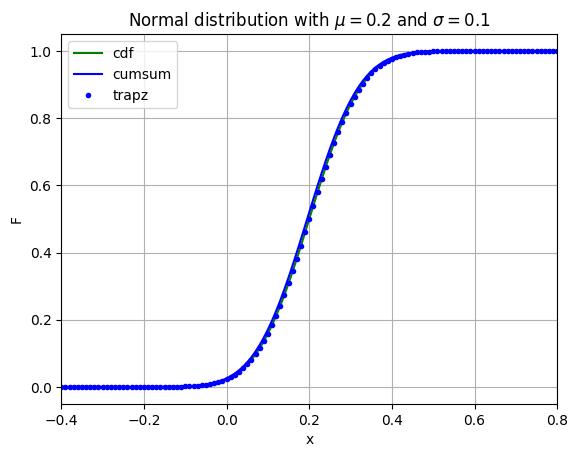

In [28]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# Define the parameters
mu = 0.2  # Mean
sigma = 0.1  # Standard deviation
a = -0.4  # Left truncation
b = 0.8  # Right truncation
nsteps = 120  # Number of grid steps

# Define the grid
deltax = (b - a) / nsteps  # Grid step
x = np.linspace(a, b, nsteps + 1)  # Grid

# Compute the PDF and CDF
f = norm.pdf(x, mu, sigma)  # PDF of the normal distribution
F = norm.cdf(x, mu, sigma)  # CDF of the normal distribution

# (a) Compute the CDF using cumsum
Fa = np.cumsum(f) * deltax

# (b) Compute the CDF using a for loop and sum
Fb = np.zeros_like(f)
for i in range(1, len(f)):
    Fb[i] = np.sum(f[:i+1])
Fb *= deltax

# (c) Compute the CDF using trapz
Fc = np.zeros_like(f)
for i in range(1, len(f)):
    Fc[i] = np.trapz(f[:i+1], dx=deltax)

# (d) Compute the CDF using the trapezoidal rule in a for loop
Fd = np.zeros_like(f)
Fd[1] = 0.5 * (f[0] + f[1])
for i in range(2, len(f)):
    Fd[i] = Fd[i-1] + 0.5 * (f[i-1] + f[i])
Fd *= deltax

# (e) Compute the CDF using a correction vector with cumsum
Fe = np.cumsum(f) - 0.5 * (f[0] + f)
Fe[0] = f[0]  # Correct the first element
Fe *= deltax

# (f) Output the first 10 and central 10 elements of the results
print("First 10 elements:")
print("F: ", F[:10])
print("Fa:", Fa[:10])
print("Fb:", Fb[:10])
print("Fc:", Fc[:10])
print("Fd:", Fd[:10])
print("Fe:", Fe[:10])

print("\nCentral 10 elements:")
central_indices = slice(nsteps//2 - 4, nsteps//2 + 6)
print("F: ", F[central_indices])
print("Fa:", Fa[central_indices])
print("Fb:", Fb[central_indices])
print("Fc:", Fc[central_indices])
print("Fd:", Fd[central_indices])
print("Fe:", Fe[central_indices])

# (g) Plot the results
plt.figure(1)
plt.plot(x, F, 'g', label="cdf")
plt.plot(x, Fa, 'b', label="cumsum")
plt.plot(x, Fc, 'b.', label="trapz")
plt.xlim([a, b])
plt.xlabel('x')
plt.ylabel('F')
plt.legend()
plt.title(r'Normal distribution with $\mu = 0.2$ and $\sigma = 0.1$')
plt.grid()
plt.savefig("normal.pdf")  # Save the plot to a file
plt.show()